In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix


import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

In [2]:
data = pd.read_csv('./data/conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [3]:
# Repartition des variables categorielles
round(data.country.value_counts(normalize=True).mul(100),2)

country
US         56.27
China      24.29
UK         15.34
Germany     4.11
Name: proportion, dtype: float64

In [4]:
# Repartion des users à partir d'un pays d'origine
round(data.new_user.value_counts(normalize=True).mul(100), 2)

new_user
1    68.55
0    31.45
Name: proportion, dtype: float64

In [5]:
round(data.source.value_counts(normalize=True).mul(100),2)

source
Seo       49.01
Ads       28.12
Direct    22.87
Name: proportion, dtype: float64

In [6]:
# la source seo sembe predominante
round(data.groupby("converted")["total_pages_visited"].value_counts(normalize = True).mul(100),2)

converted  total_pages_visited
0          2                      14.36
           3                      14.33
           4                      13.39
           1                      13.30
           5                      11.84
           6                       9.84
           7                       7.62
           8                       5.64
           9                       3.85
           10                      2.49
           11                      1.55
           12                      0.89
           13                      0.47
           14                      0.24
           15                      0.11
           16                      0.05
           17                      0.02
           18                      0.01
           19                      0.00
           20                      0.00
1          14                     10.32
           13                      9.74
           15                      9.64
           16                      9.43
         

In [7]:
# Taux de conversion
round(data.converted.value_counts(normalize=True).mul(100),2)

converted
0    96.77
1     3.23
Name: proportion, dtype: float64

In [8]:
# Visualisation des variables


mu = data['age'].mean()
std = data['age'].std()
min = round((mu - 2*std))
max = round((mu + 2*std))
print("âge minimum à 2 écart type de la moyenne:", min, "\n"  "âge maximum à 2 écart type de la moyenne:",max)



âge minimum à 2 écart type de la moyenne: 14 
âge maximum à 2 écart type de la moyenne: 47


In [9]:
print("l'âge moyen des utilisateurs : {}".format(round(data['age'].mean())))
print("l'écart type : {}".format(round(data['age'].std())))

l'âge moyen des utilisateurs : 31
l'écart type : 8


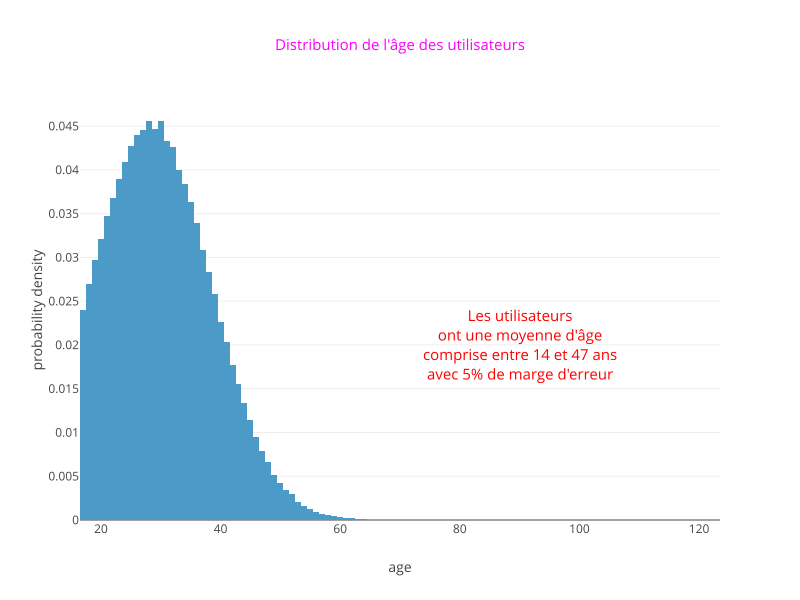

In [10]:


fig = px.histogram(
    data, 
    x='age', 
    nbins=150, 
    histnorm='probability density',
    title="Distribution de l'âge des utilisateurs",
    width=800,
    height=600
)

# Personnalisation du titre
fig.update_layout(
    title_font=dict(size=15, color='magenta')
)

# Ajout du texte d'annotation (les sauts de ligne utilisent <br>)
fig.add_annotation(
    x=90,
    y=0.02,
    text="Les utilisateurs <br> ont une moyenne d'âge<br> comprise entre 14 et 47 ans<br> avec 5% de marge d'erreur",
    showarrow=False,
    font=dict(size=15, color='red'),
    align="center"
)

fig.show()



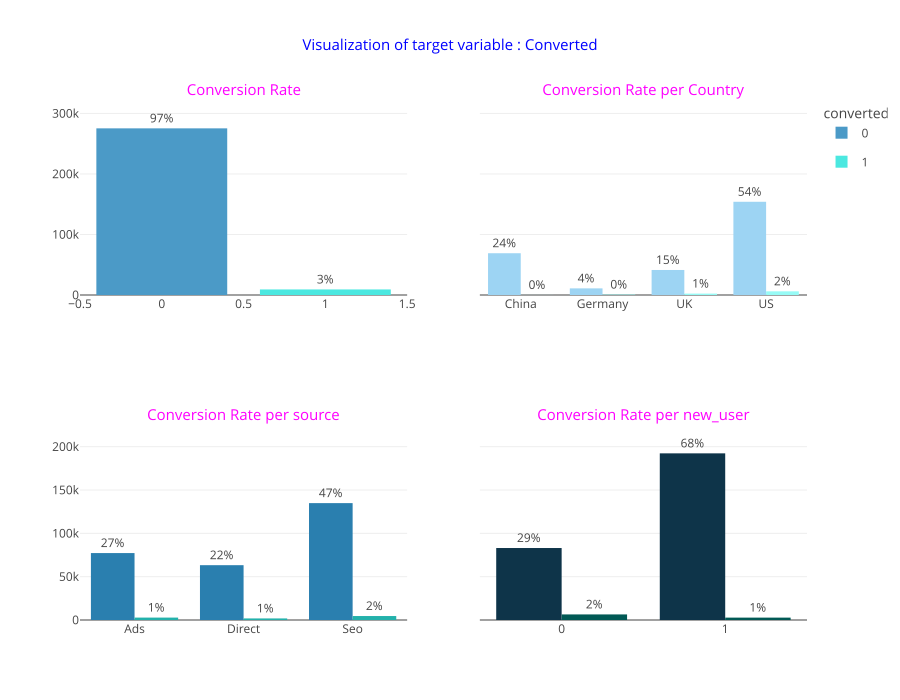

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

total = len(data)

fig = make_subplots(
    rows=2, cols=2,
    shared_yaxes=True,
    subplot_titles=(
        "Conversion Rate", 
        "Conversion Rate per Country", 
        "Conversion Rate per source", 
        "Conversion Rate per new_user"
    )
)

columns = [
    ("converted", 1, 1),
    ("country", 1, 2),
    ("source", 2, 1),
    ("new_user", 2, 2)
]

for col, row, c_idx in columns:
    # Évite la duplication de la colonne 'converted' dans le groupby
    group_cols = [col] if col == 'converted' else [col, 'converted']
    
    df_grouped = data.groupby(group_cols).size().reset_index(name='count')
    df_grouped['pct'] = (df_grouped['count'] / total).map('{:.0%}'.format)
    
    for val in sorted(data['converted'].unique()):
        df_sub = df_grouped[df_grouped['converted'] == val]
        
        fig.add_trace(
            go.Bar(
                x=df_sub[col].astype(str),
                y=df_sub['count'],
                text=df_sub['pct'],
                textposition='outside',
                name=f"{val}",
                legendgroup=str(val),
                showlegend=(row == 1 and c_idx == 1)
            ),
            row=row, col=c_idx
        )

fig.update_layout(
    title_text="Visualization of target variable : Converted",
    title_font=dict(size=15, color='blue'),
    barmode='group',
    height=700,
    width=900,
    legend_title_text="converted"
)

for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=15, color='magenta')

fig.show()

- Le taux de conversion est très faible.
- Les USA a le plus grand nombre d'utilisateurs et de taux de conversion
- La source Seo est la plus performante en matière de génération de traffic

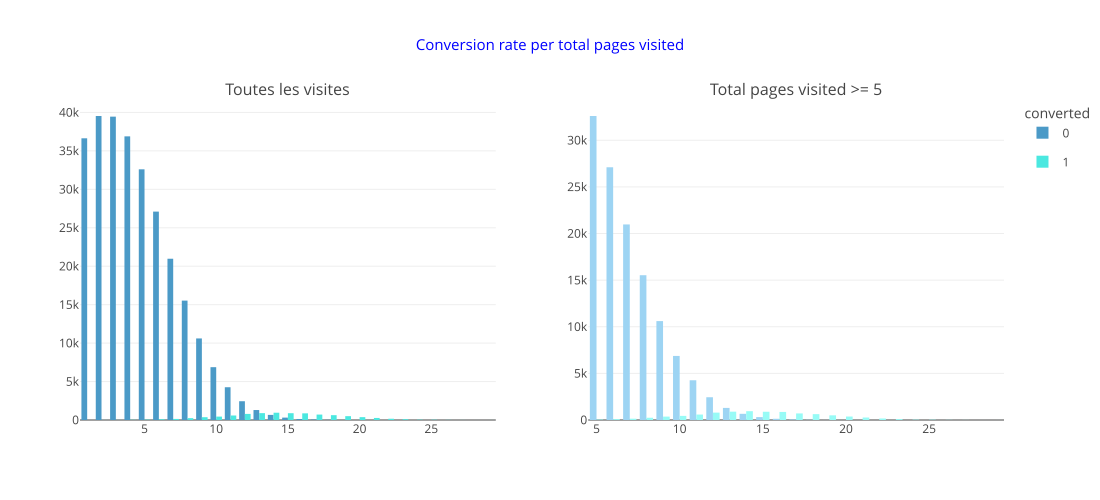

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Création de la grille 1x2
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Toutes les visites", "Total pages visited >= 5")
)

# 1. Graphique de gauche : Toutes les données
df_all = data.groupby(['total_pages_visited', 'converted']).size().reset_index(name='count')

for val in sorted(data['converted'].unique()):
    sub = df_all[df_all['converted'] == val]
    fig.add_trace(
        go.Bar(
            x=sub['total_pages_visited'],
            y=sub['count'],
            name=str(val),
            legendgroup=str(val)
        ),
        row=1, col=1
    )

# 2. Graphique de droite : Filtré pour >= 5 pages
data_filtered = data[data['total_pages_visited'] >= 5]
df_filt = data_filtered.groupby(['total_pages_visited', 'converted']).size().reset_index(name='count')

for val in sorted(data['converted'].unique()):
    sub = df_filt[df_filt['converted'] == val]
    fig.add_trace(
        go.Bar(
            x=sub['total_pages_visited'],
            y=sub['count'],
            name=str(val),
            legendgroup=str(val),
            showlegend=False # Évite de doubler la légende
        ),
        row=1, col=2
    )

# Mise en forme globale
fig.update_layout(
    title_text="Conversion rate per total pages visited",
    title_font=dict(size=15, color='blue'),
    barmode='group',
    height=500,
    width=1100,
    legend_title_text="converted"
)

fig.show()

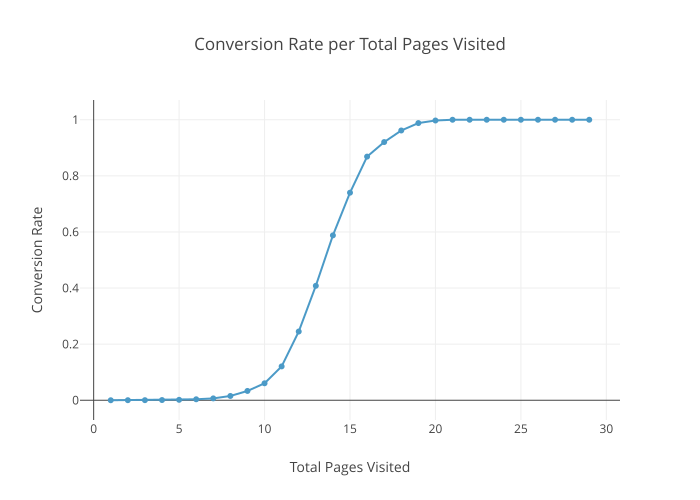

In [13]:


# Calcul du taux de conversion moyen par nombre de pages visitées
df_grouped = data.groupby('total_pages_visited')['converted'].mean().reset_index()

fig = px.line(
    df_grouped, 
    x='total_pages_visited', 
    y='converted',
    labels={'total_pages_visited': 'Total Pages Visited', 'converted': 'Conversion Rate'},
    title="Conversion Rate per Total Pages Visited"
)

# Optionnel : ajoute des marqueurs sur chaque point de la ligne
fig.update_traces(mode='lines+markers')

fig.show()

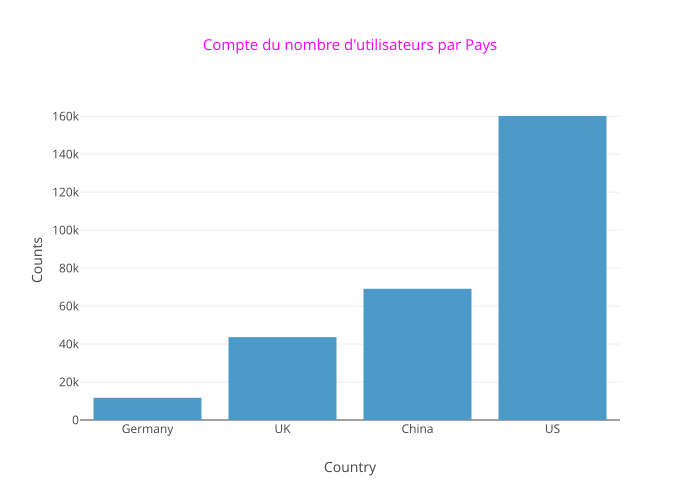

In [14]:

# Préparation des données (triées par ordre croissant de comptage)
country = data['country'].value_counts()
df_country = pd.DataFrame({"Country": country.index, "Counts": country.values}).sort_values(by="Counts", ascending=True)

# Création du graphique en barres
fig = px.bar(
    df_country, 
    x="Country", 
    y="Counts",
    title="Compte du nombre d'utilisateurs par Pays"
)

# Personnalisation du titre
fig.update_layout(
    title_font=dict(size=15, color='magenta')
)

fig.show()

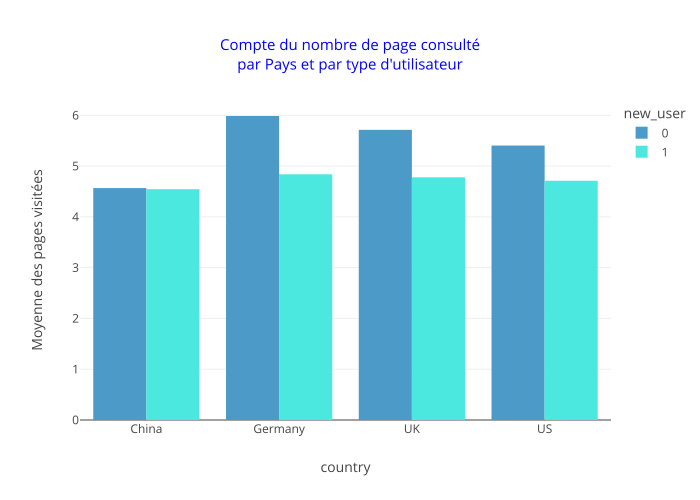

In [15]:

# 1. Calcul de la moyenne des pages visitées par pays et par type d'utilisateur
df_grouped = data.groupby(['country', 'new_user'])['total_pages_visited'].mean().reset_index()

# 
df_grouped['new_user'] = df_grouped['new_user'].astype(str)

# 2. Création du graphique en barres groupées
fig = px.bar(
    df_grouped, 
    x="country", 
    y="total_pages_visited", 
    color="new_user", 
    barmode="group",
    title="Compte du nombre de page consulté<br> par Pays et par type d'utilisateur"
)

# 3. Personnalisation du titre et de l'axe Y
fig.update_layout(
    title_font=dict(size=15, color='blue'),
    yaxis_title="Moyenne des pages visitées"
)

fig.show()

In [16]:
converted_count = pd.DataFrame(data.converted.value_counts(), index = data.converted.unique())
converted_count.index = ["No","Yes"]
converted_count

,count
No,275400
Yes,9180


In [17]:
country_count = pd.DataFrame({"Country":data.country.value_counts().values}, index =[i for i in data.country.value_counts().index])
country_count

,Country
US,160124
China,69122
UK,43641
Germany,11693


In [18]:
converted_yes_count = data[data["converted"]==1]
print("Total Count of customers converted : ",data.converted.value_counts().values[1])
converted_yes_country_count = pd.DataFrame({"Country":converted_yes_count.country.value_counts().values}, index =[i for i in converted_yes_count.country.value_counts().index])
converted_yes_country_count

Total Count of customers converted :  9180


,Country
US,6070
UK,2291
Germany,730
China,89


Total Count of customers converted : 9180


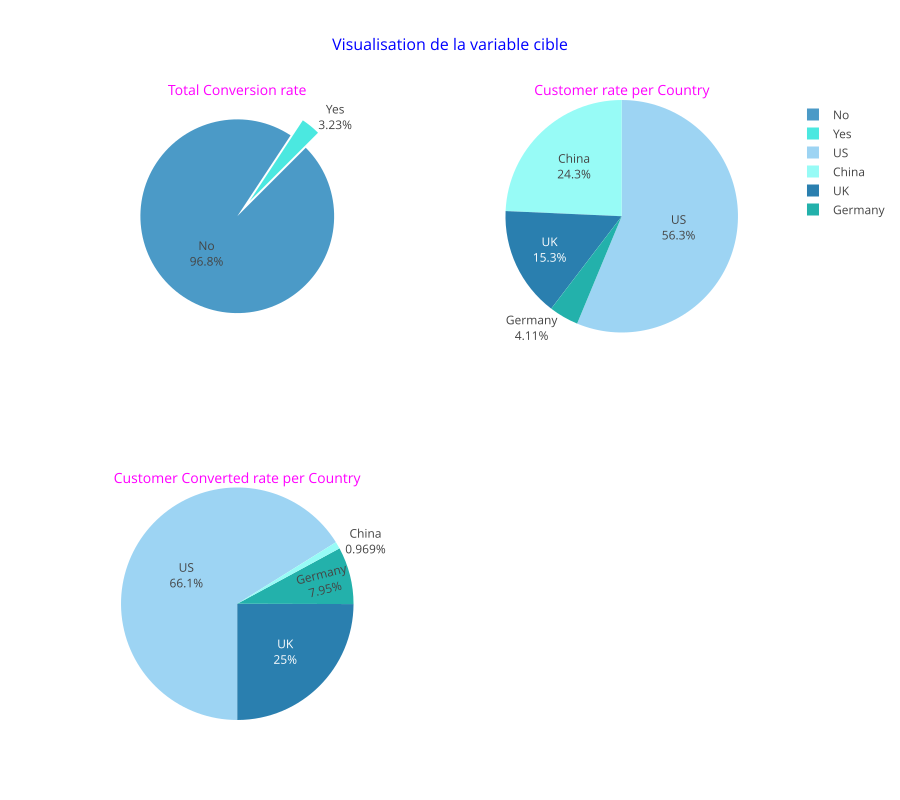

In [19]:

converted_count = data['converted'].value_counts().rename(index={0: "No", 1: "Yes"})
country_count = data['country'].value_counts()
converted_yes_country_count = data.loc[data['converted'] == 1, 'country'].value_counts()

print("Total Count of customers converted :", converted_count["Yes"])

# --- Figure : grille 2x2 de camemberts (type "domain") ---
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "domain"}, {"type": "domain"}],
           [{"type": "domain"}, {"type": "domain"}]],
    subplot_titles=(
        "Total Conversion rate",
        "Customer rate per Country",
        "Customer Converted rate per Country",
        ""
    )
)

fig.add_trace(
    go.Pie(
        labels=converted_count.index,
        values=converted_count.values,   
        rotation=45,
        textinfo='percent+label',
        pull=[0, 0.2]                    
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=country_count.index,
        values=country_count.values,
        rotation=0,
        textinfo='percent+label'
    ),
    row=1, col=2
)

fig.add_trace(
    go.Pie(
        labels=converted_yes_country_count.index,
        values=converted_yes_country_count.values,
        rotation=180,
        textinfo='percent+label'
    ),
    row=2, col=1
)


fig.update_layout(
    height=800,
    width=900,
    title_text="Visualisation de la variable cible",
    title_font=dict(size=16, color='blue'),
    showlegend=True
)


for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, color='magenta')

fig.show()


In [20]:
corr = data.corr(numeric_only=True)
#corr = corr.converted.sort_values(ascending = False)
#corr = abs(corr.converted.sort_values(ascending = False))
corr

,age,new_user,total_pages_visited,converted
age,1.000000,0.011676,-0.045365,-0.088265
new_user,0.011676,1.000000,-0.082986,-0.152115
total_pages_visited,-0.045365,-0.082986,1.000000,0.529192
converted,-0.088265,-0.152115,0.529192,1.000000


In [21]:
# Separate target variable Y from features X
print("Separating labels from features...")
features_list = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
target_variable = "converted"
categorical_indices = [0,3]
numeric_indices = [1,2,4]


X = data.loc[:,features_list]
y = data.loc[:,target_variable]

print("...Done.")
print()

print('y : ')
print(y.head())
print()
print('X :')
print(X.head())

Separating labels from features...
...Done.

y : 
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

X :
   country  age  new_user  source  total_pages_visited
0    China   22         1  Direct                    2
1       UK   21         1     Ads                    3
2  Germany   20         0     Seo                   14
3       US   23         1     Seo                    3
4       US   28         1  Direct                    3


In [22]:
# Divide dataset Train set & Test set 
from sklearn.model_selection import train_test_split
print("Dividing into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.33, random_state=42, stratify = y)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [23]:
print("Convert pandas DataFrames to numpy arrays...")
X_train = X_train.values
X_test = X_test.values
y_train = y_train.tolist()
y_test = y_test.tolist()
print("...Done")

print(X_train[0:5,:])
print(X_test[0:2,:])
print()
print(y_train[0:5])
print(y_test[0:2])

Convert pandas DataFrames to numpy arrays...
...Done
[['US' 21 1 'Seo' 6]
 ['US' 35 1 'Seo' 4]
 ['US' 39 1 'Ads' 4]
 ['US' 43 1 'Seo' 4]
 ['China' 30 1 'Ads' 1]]
[['US' 31 1 'Ads' 2]
 ['US' 18 1 'Seo' 2]]

[0, 0, 0, 0, 0]
[0, 0]


In [24]:
# Encoding categorical features and standardizing numerical features
from sklearn.preprocessing import  OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

In [25]:
print("Encoding categorical features and standardizing numerical features...")
print()
print(X_train[0:5,:])

# Normalization
numeric_transformer = StandardScaler()

# OHE / dummyfication
categorical_transformer = OneHotEncoder(drop='first')

featureencoder = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_indices),    
        ('num', numeric_transformer, numeric_indices)
        ]
    )

X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])

Encoding categorical features and standardizing numerical features...

[['US' 21 1 'Seo' 6]
 ['US' 35 1 'Seo' 4]
 ['US' 39 1 'Ads' 4]
 ['US' 43 1 'Seo' 4]
 ['China' 30 1 'Ads' 1]]
...Done
[[ 0.          0.          1.          0.          1.         -1.15588691
   0.67657298  0.33785797]
 [ 0.          0.          1.          0.          1.          0.5345819
   0.67657298 -0.261071  ]
 [ 0.          0.          1.          0.          0.          1.017573
   0.67657298 -0.261071  ]
 [ 0.          0.          1.          0.          1.          1.50056409
   0.67657298 -0.261071  ]
 [ 0.          0.          0.          0.          0.         -0.06915696
   0.67657298 -1.15946446]]


In [26]:
from sklearn.linear_model import LogisticRegressionCV
print("Train model...")
classifier = LogisticRegressionCV(class_weight={0:0.50,1:0.8}, cv=10) # regularized logit with regularization strength chosen by cross-val
%time classifier.fit(X_train, y_train)
print("...Done.")

Train model...


/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified i

CPU times: user 39.1 s, sys: 419 ms, total: 39.5 s
Wall time: 5.26 s
...Done.


In [27]:
print("Predictions on training set...")
y_train_pred = classifier.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



In [28]:
# Encoding categorical features and standardizing numerical features
print("Encoding categorical features and standardizing numerical features...")
print()
X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5,:])

Encoding categorical features and standardizing numerical features...

...Done
[[ 0.          0.          1.          0.          0.          0.05159081
   0.67657298 -0.85999997]
 [ 0.          0.          1.          0.          1.         -1.51813023
   0.67657298 -0.85999997]
 [ 0.          1.          0.          1.          0.          1.13832077
   0.67657298  0.93678695]
 [ 0.          0.          1.          0.          1.         -0.91439137
   0.67657298 -0.85999997]
 [ 0.          0.          1.          1.          0.          0.41383413
   0.67657298 -0.56053549]]


In [29]:
print("Predictions on test set...")
y_test_pred = classifier.predict(X_test)
print("...Done.")
print(y_test_pred)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
print("f1-score on train set : {:06.4f} " .format(f1_score(y_train, y_train_pred)))
print("f1-score on test set : {:06.4f} " .format(f1_score(y_test, y_test_pred)))

f1-score on train set : 0.7708 
f1-score on test set : 0.7675 


In [31]:
print("Accuray on test set : {:06.4f} " .format(classifier.score(X_test, y_test)))

Accuray on test set : 0.9855 


In [ ]:

print("Confusion matrix on train set : ")
print(confusion_matrix(y_train, y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(y_test, y_test_pred))
print()

Confusion matrix on train set : 
[[183412   1105]
 [  1601   4550]]

Confusion matrix on test set : 
[[90313   570]
 [  788  2241]]



In [33]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
y = np.append(y_train,y_test)

%time classifier.fit(X,y)

/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified i

CPU times: user 47.8 s, sys: 373 ms, total: 48.2 s
Wall time: 7.07 s


,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 class_weight == 'balanced'","{0: 0.5, 1: 0.8}"
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add an L2 penalty term (used by default);- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy <accuracy_score>` is used... versionchanged:: 1.11 The default will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11.",'warn'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problem

In [35]:
# Read data without labels (The real X_test)
data_without_labels = pd.read_csv("./data/conversion_data_test.csv")
print('Prediction set (without labels) :', data_without_labels.shape)


#features_list = ['total_pages_visited']
X_without_labels = data_without_labels.loc[:]

# Convert pandas DataFrames to numpy arrays before using scikit-learn
#print("Convert pandas DataFrames to numpy arrays...")
#X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels.head())

Prediction set (without labels) : (31620, 5)
...Done
  country  age  new_user  source  total_pages_visited
0      UK   28         0     Seo                   16
1      UK   22         1  Direct                    5
2   China   32         1     Seo                    1
3      US   32         1     Ads                    6
4   China   25         0     Seo                    3


In [36]:
# Encoding categorical features and standardizing numerical features
print("Encoding categorical features and standardizing numerical features...")
X_without_labels = featureencoder.transform(X_without_labels)
print('Done.')
print()

Encoding categorical features and standardizing numerical features...
Done.



/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/home/henintsoa/miniconda3/envs/walmart/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [37]:
model1 = {
    'converted': classifier.predict(X_without_labels)
}

y_predictions = pd.DataFrame(columns=['converted'],data=model1)
y_predictions.to_csv('conversion_data_test.csv', index=False)